In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'

computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path


# variable2 = 'shelfmelt'
# factor = -1* 365.25 * 24 * 3600/900
# pth = pth_helene
variable = 'iareafl'


variable2 = 'shelfmelt'
factor = -1* 365.25 * 24 * 3600/900
pth = pth_helene
fpath = f'./figs/avg_{variable2}/'
fname = f'average_{variable2}_'

In [22]:

mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]


In [23]:
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
dic_area_of_interest['WestAntarctica'] = ['_region_1']
dic_area_of_interest['EastAntarctica'] = ['_region_2']
dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['Filchner_Ronne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']

                                
regionnumbers = [2, 5, 6, 9, 11, 16]
lst = []
for r in regionnumbers:
    lst.append(f'_sector_{r}')
dic_area_of_interest['mode1']   = lst                             
                                
regionnumbers = [1, 3, 4, 8, 18]
lst = []
for r in regionnumbers:
    lst.append(f'_sector_{r}')
dic_area_of_interest['mode2']   = lst   

regionnumbers = [ 7, 10, 12, 13, 14, 15,  17] 
lst = []
for r in regionnumbers:
    lst.append(f'_sector_{r}')
dic_area_of_interest['mode_rest']   = lst   

The path './figs/avg_shelfmelt/' already exists.


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_70880/183210464.py:46: RuntimeWarning: invalid value encountered in divide
  the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable}{nm}'].values[:tmin]
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_70880/183210464.py:46: RuntimeWarning: invalid value encountered in divide
  the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable}{nm}'].values[:tmin]
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_70880/183210464.py:46: RuntimeWarning: invalid value encountered in divide
  the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable}{nm}'].values[:tmin]
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_70880/183210464.py:46: RuntimeWarning: invalid value encountered in divide
  the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable}{nm}'].values[:tmin]
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_70880/183210464.py:46: Ru

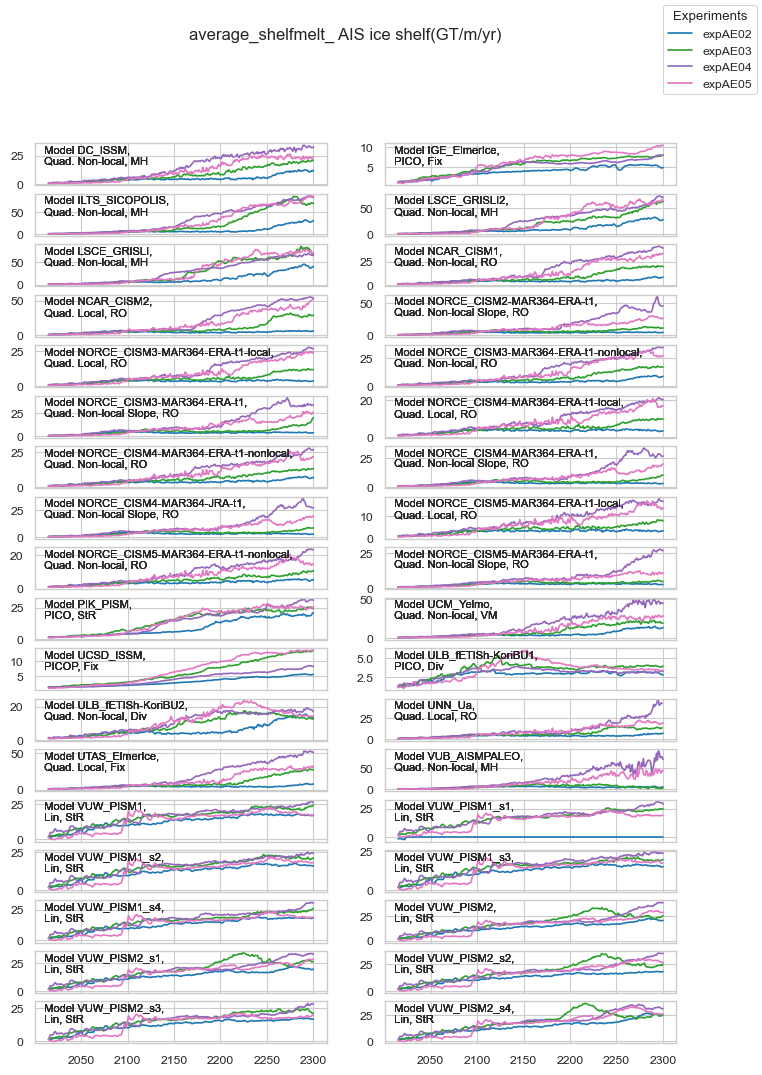

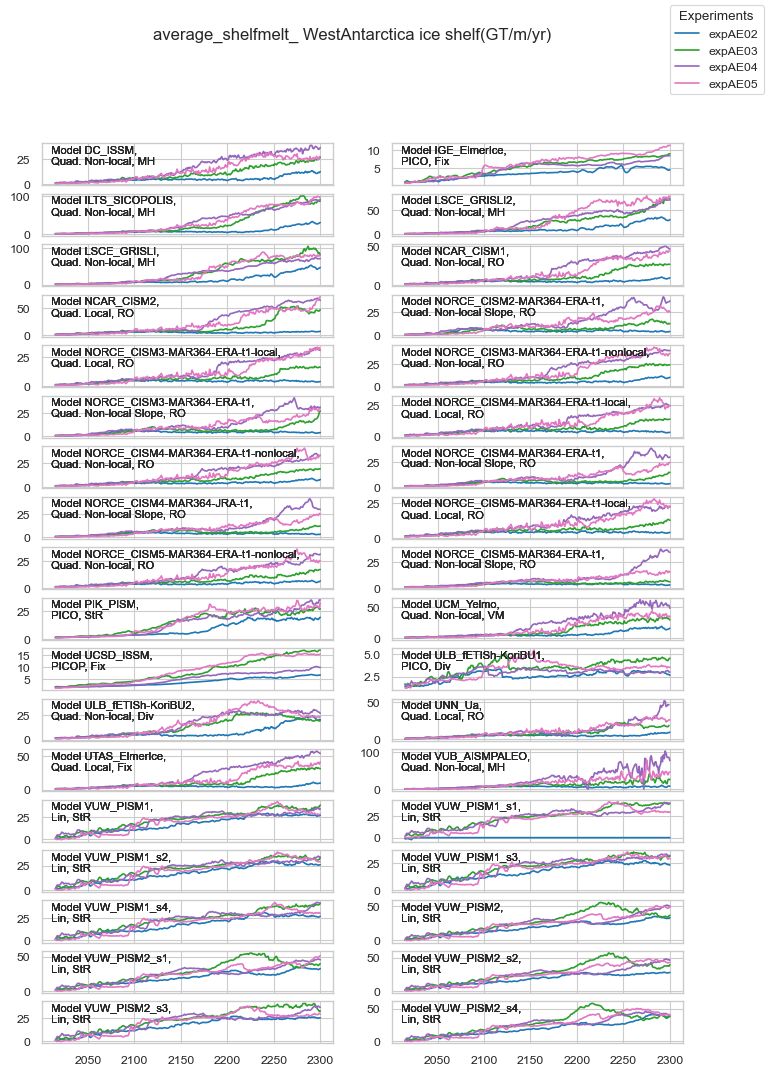

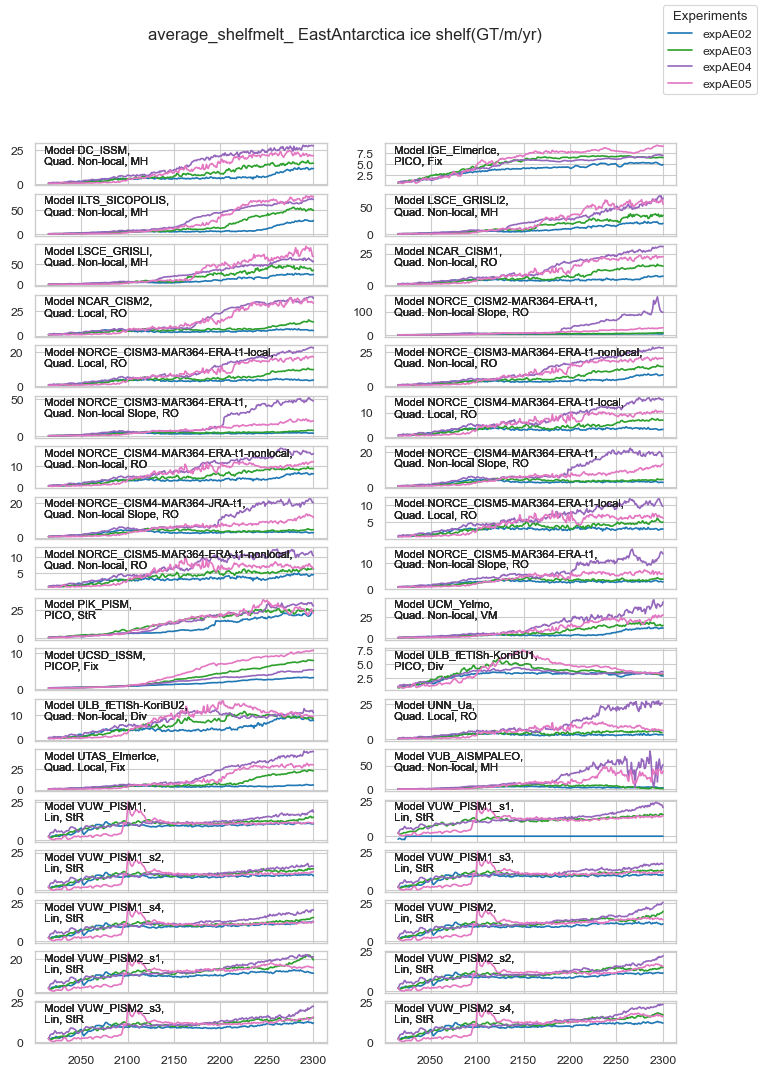

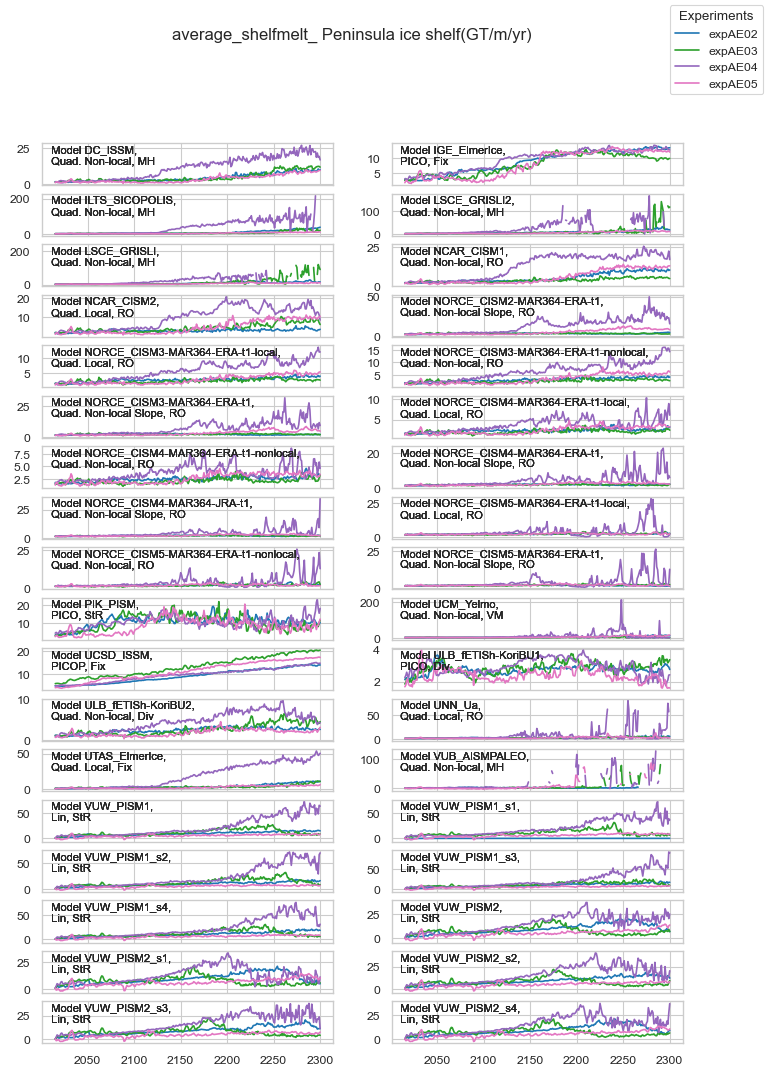

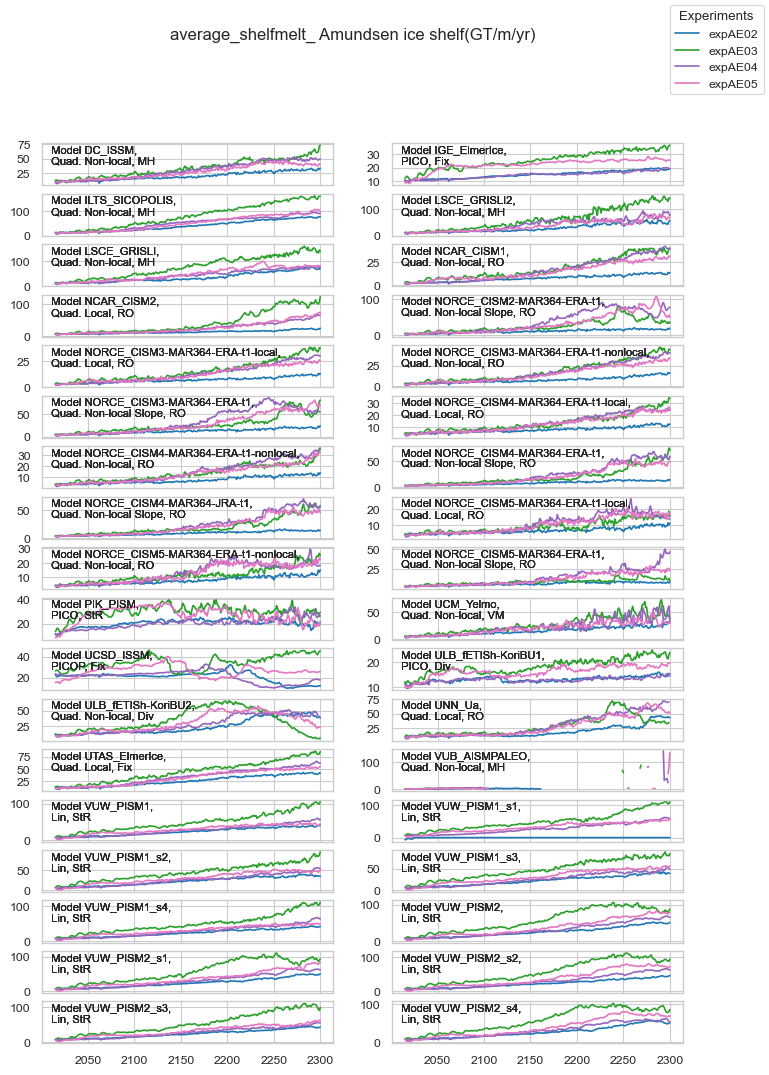

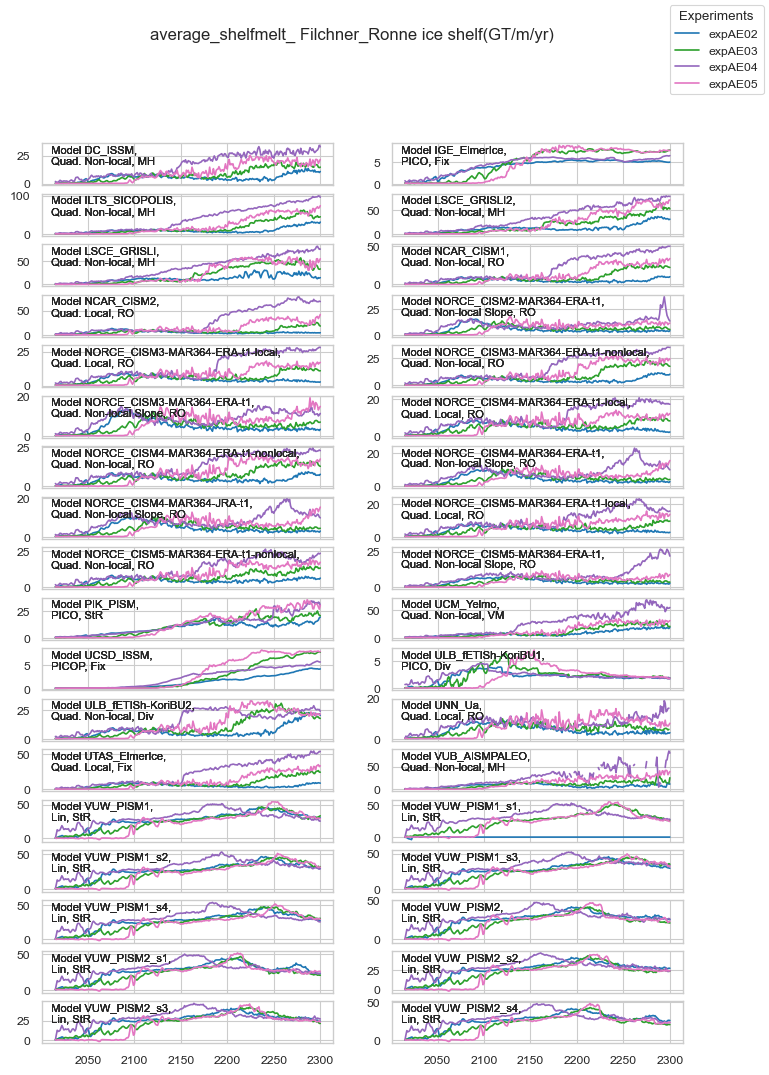

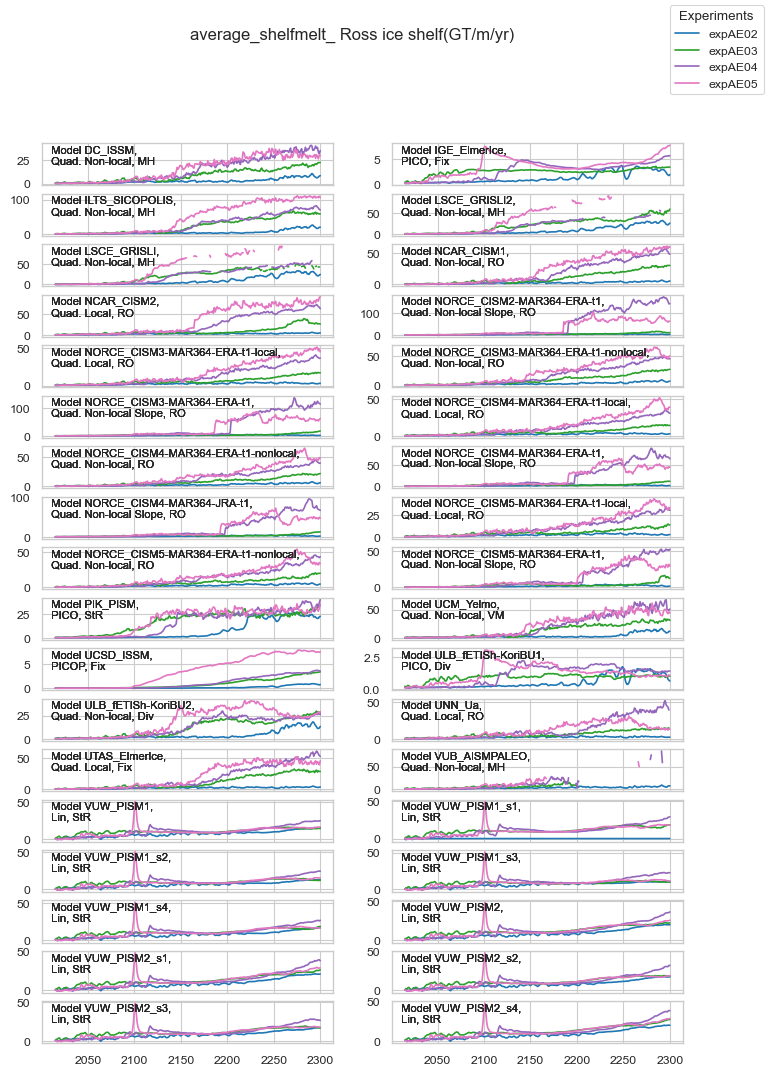

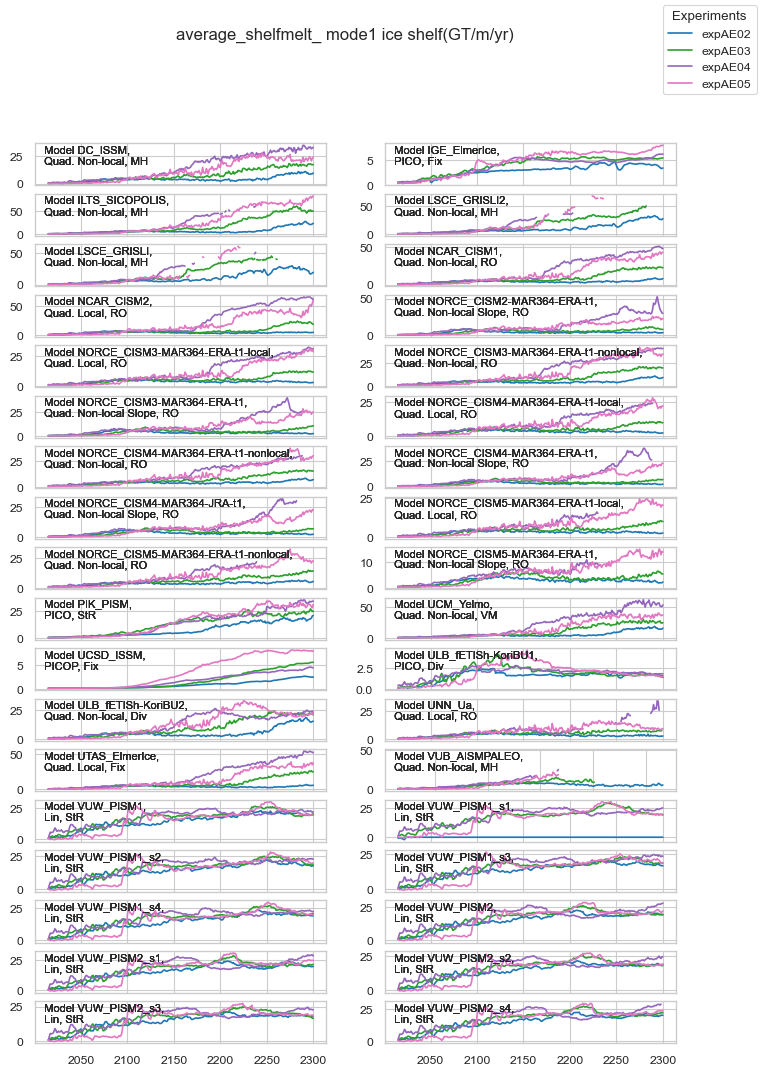

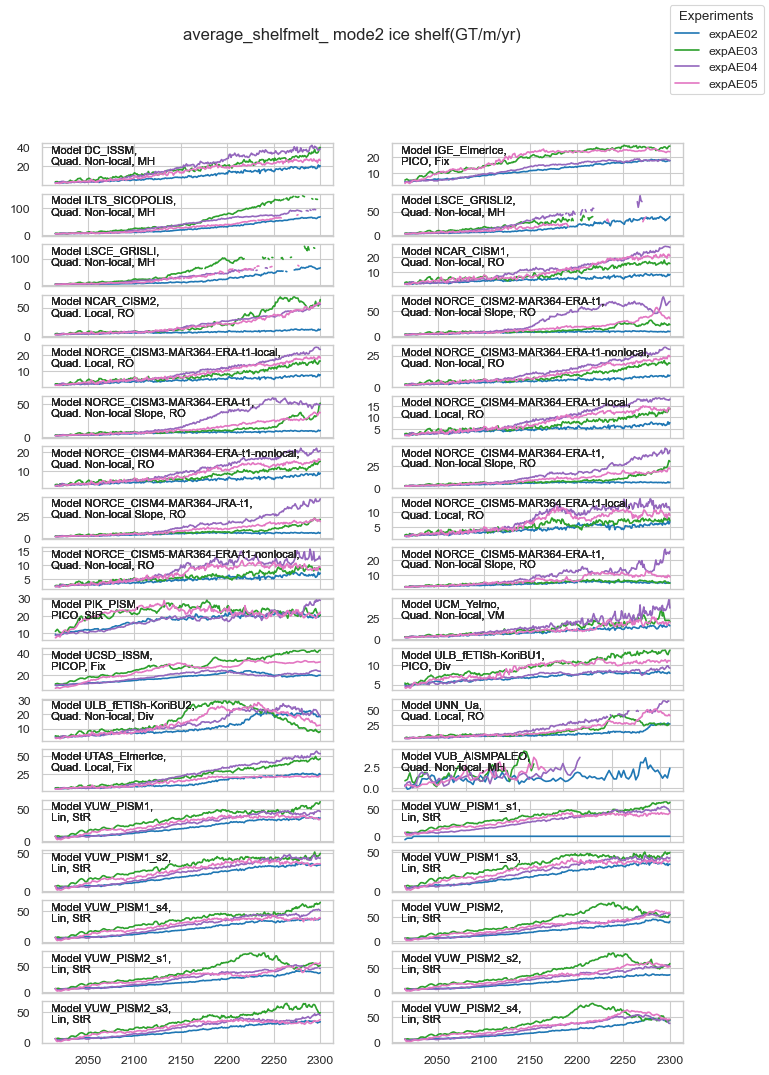

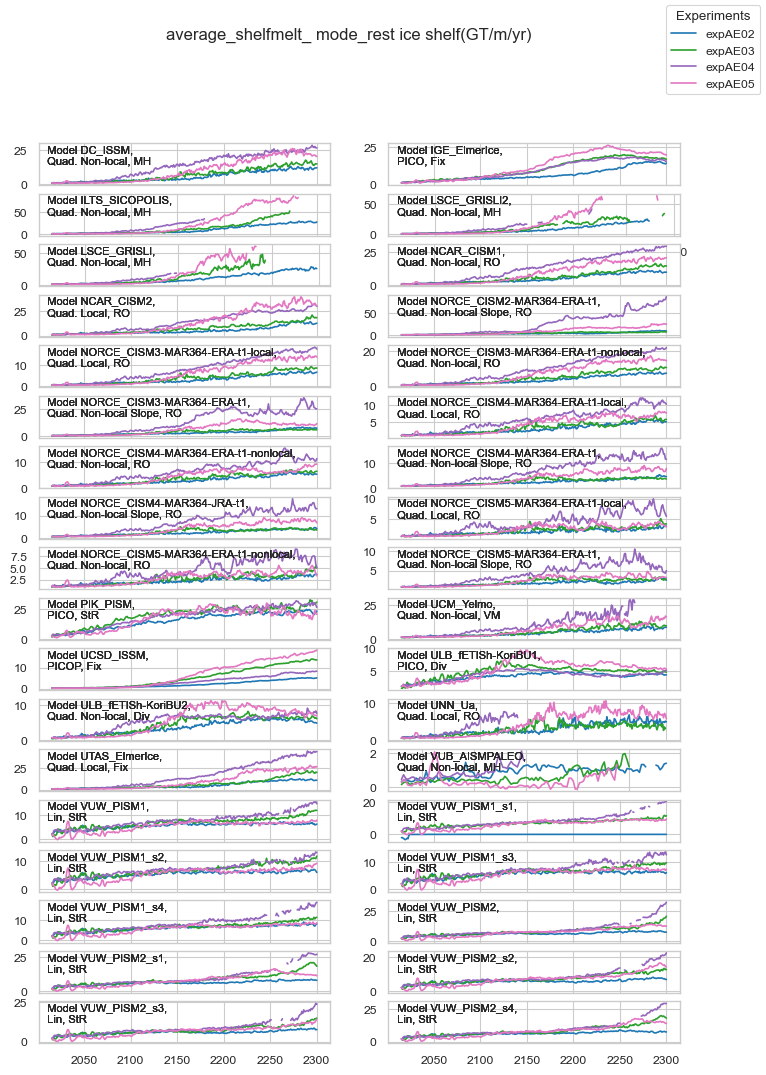

In [24]:
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")

for key in dic_area_of_interest.keys():
   
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
    fs = 8

    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    f,ax = plt.subplots(df.shape[0]//2,2,figsize=(a4_width, a4_height))
    for j,exp in enumerate(expnames):
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        for i in range (df.shape[0]):
            ix =i //2
            iy=i%2
            pth_way = df.iloc[i].Path
            #get shelf area
            pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/{variable}/computed_{variable}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

            pth_tf = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

            # Melting
            d = xr.open_dataset(pth_way,decode_times=False )
            # Area
            d2 = xr.open_dataset(pth_area,decode_times=False )
            #thermal foring 
            d3 = xr.open_dataset(pth_tf,decode_times=False )


            tmin = np.min([d.time.size,d3.time.size])
            #melting per area
            the_ys = np.zeros((len(lst),tmin))
            the_areas = np.zeros((len(lst),tmin))
            
            for k,nm in enumerate(lst):
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor/d2[f'{variable}{nm}'].values[:tmin]
                the_areas[k ,:]= d2[f'{variable}{nm}'].values[:tmin]

            
            y = np.sum(the_ys*the_areas,axis =0)/the_areas.sum(axis = 0)
            ax2 = ax[ix,iy]
            ax2.plot(d.time[:tmin],y ,color = colors[j],label = f'{exp}')
            df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
            df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
            meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
            icefront =  df_info_model_exp['ice front'].values[0]

            ax2.text(0.02, 0.98,f' Model {df.iloc[i].Model},\n {meltparam}, {icefront}',transform=ax2.transAxes,fontsize = fs, va='top')
    #         ax[ix, iy].text(0.02, 0.98, f'Experiment {exp} - Model {df.iloc[i].Model}', transform=ax[ix, iy].transAxes, fontsize=12, va='top')

    #         f.text(0.02, 0.98,
    handles, labels = ax[0, 0].get_legend_handles_labels()
    f.legend(handles, labels, loc='upper right', title='Experiments')

    f.suptitle(f'{fname} {key} ice shelf(GT/m/yr)',fontsize = 12)
    f.savefig(f'{fpath}{fname}_{key}.pdf')
#     for j in range(1,19):

In [49]:
df.iloc[i].Path